In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_excel(
    r"E:\Regional Sales Dataset.xlsx",
    sheet_name="Sales Orders"
)
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  float64       
dtypes: d

In [4]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["Month"] = df["OrderDate"].dt.to_period("M").astype(str)
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Month
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,2014-01
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,2014-01
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,2014-01
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,2014-01
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,2014-01


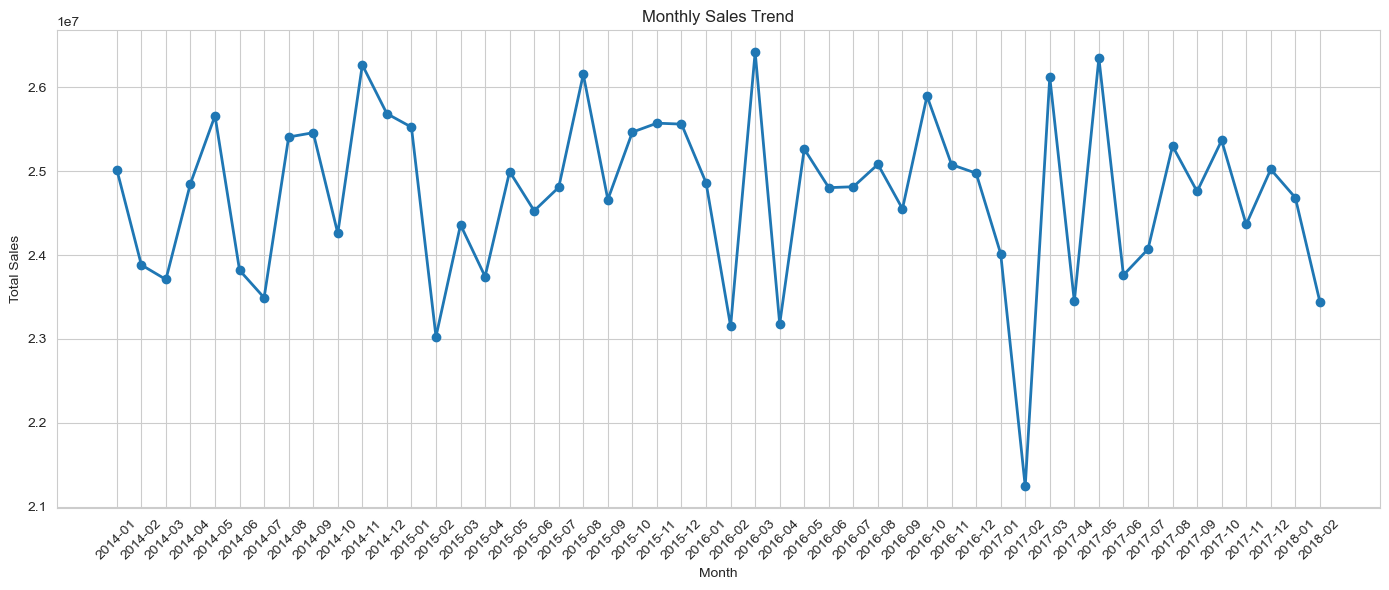

In [5]:
monthly_sales = df.groupby("Month")["Line Total"].sum()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

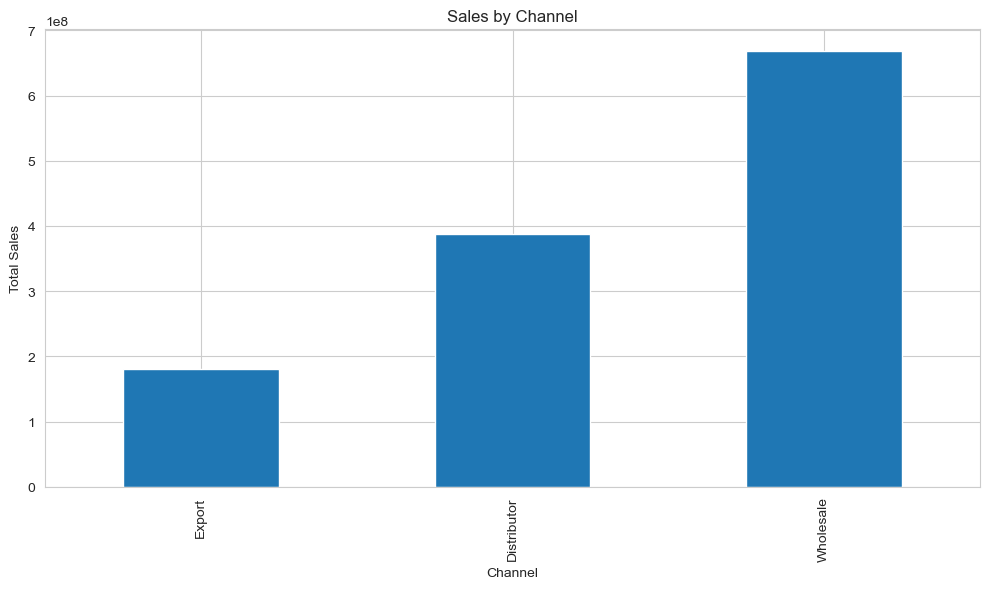

In [6]:
channel_sales=df.groupby("Channel")["Line Total"].sum().sort_values()

plt.figure(figsize=(10,6))
channel_sales.plot(kind="bar")
plt.title("Sales by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

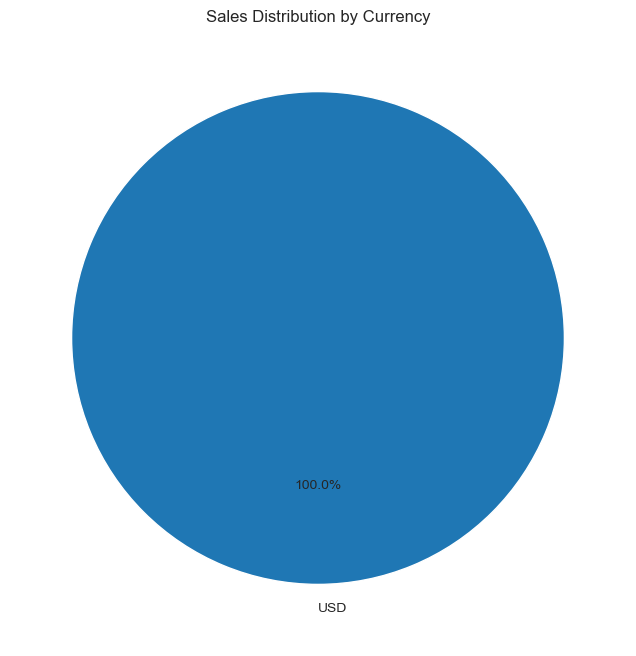

In [7]:
currency_sales=df.groupby("Currency Code")["Line Total"].sum()

plt.figure(figsize=(8,8))
plt.pie(currency_sales,
        labels=currency_sales.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Sales Distribution by Currency")
plt.show()

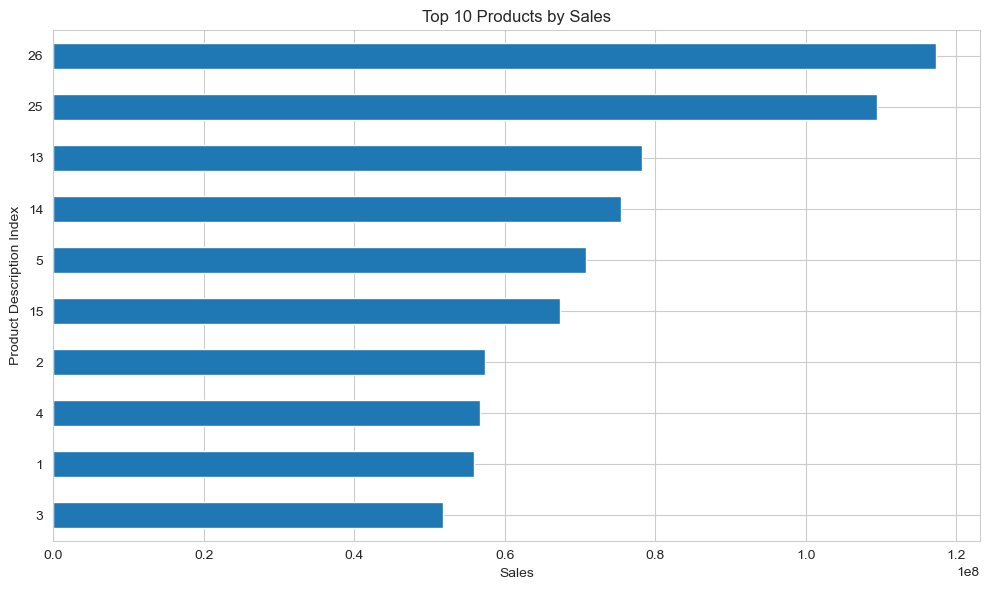

In [8]:
top_products=(df.groupby("Product Description Index")["Line Total"]
                .sum()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

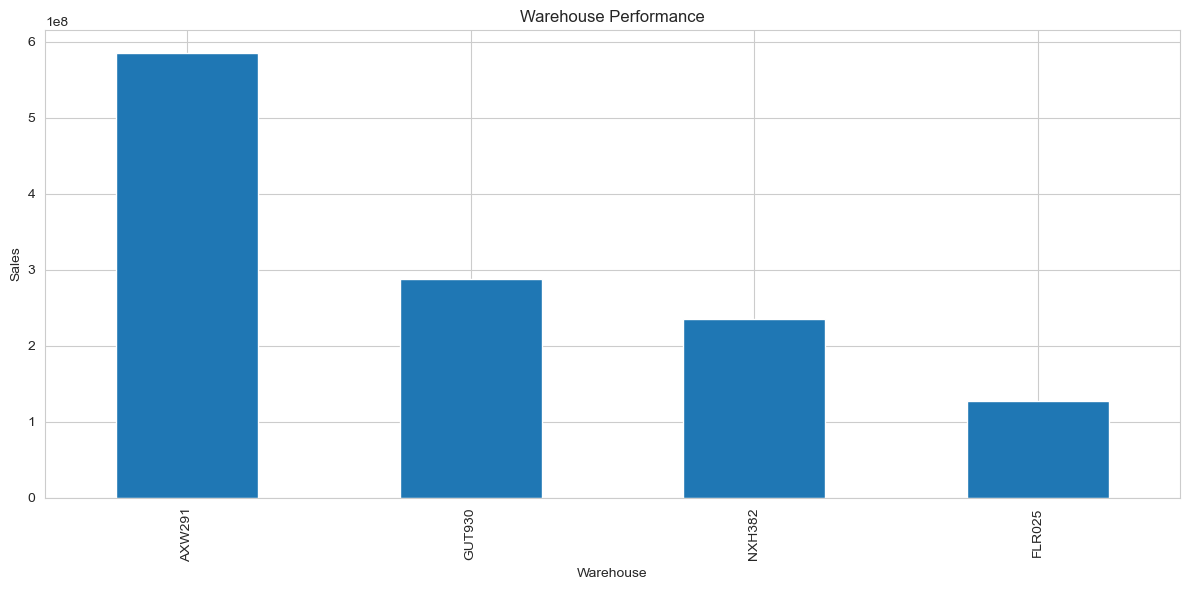

In [9]:
warehouse=df.groupby("Warehouse Code")["Line Total"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
warehouse.plot(kind="bar")
plt.title("Warehouse Performance")
plt.xlabel("Warehouse")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

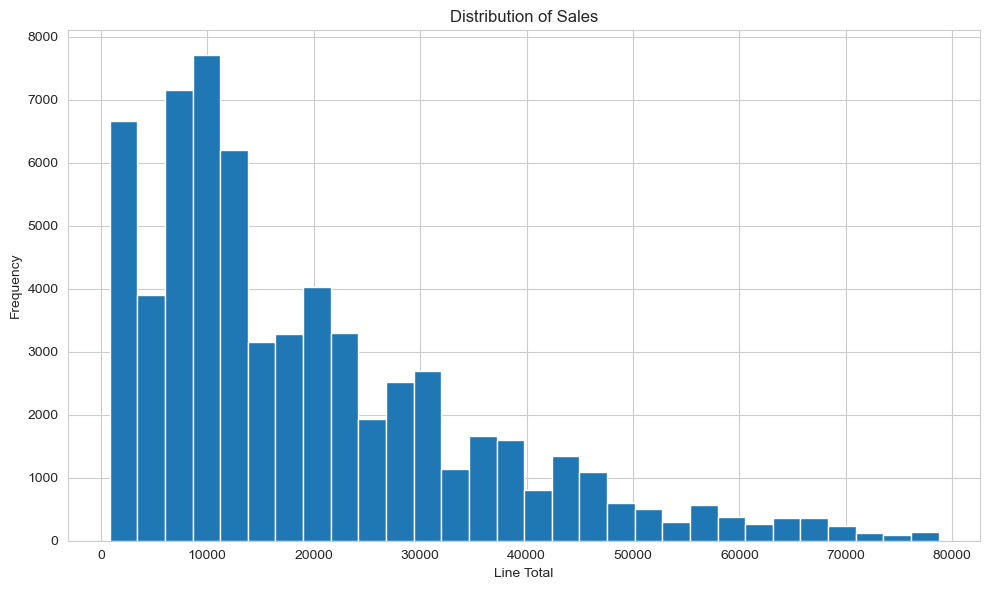

In [10]:
plt.figure(figsize=(10,6))
plt.hist(df["Line Total"],bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Line Total")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

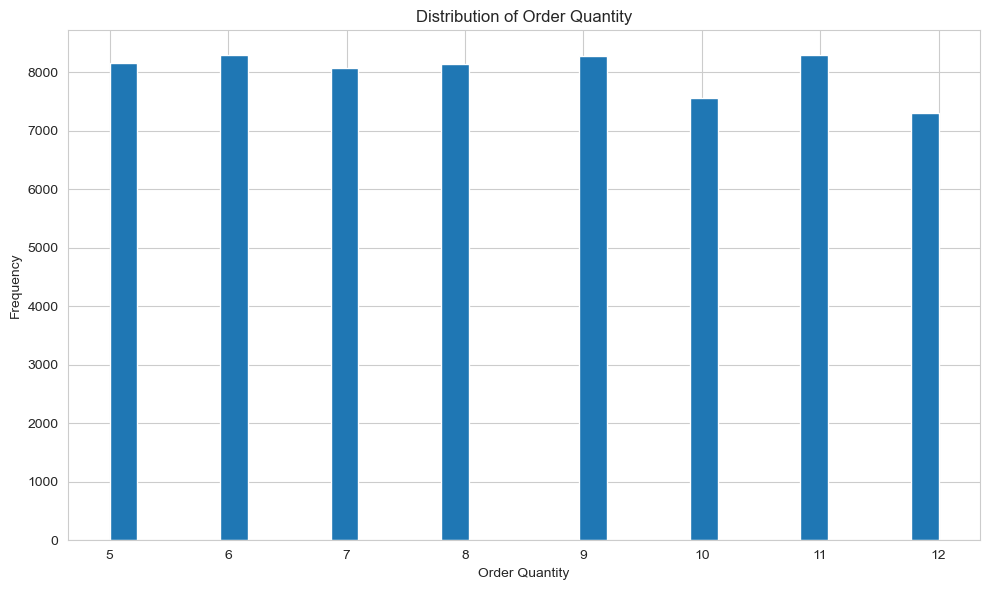

In [11]:
plt.figure(figsize=(10,6))
plt.hist(df["Order Quantity"],bins=30)
plt.title("Distribution of Order Quantity")
plt.xlabel("Order Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

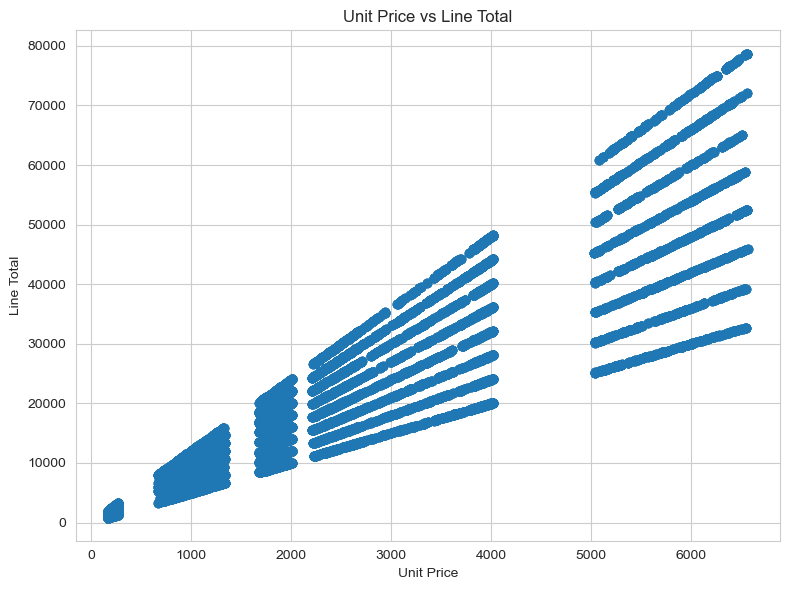

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(df["Unit Price"],df["Line Total"],alpha=0.6)
plt.title("Unit Price vs Line Total")
plt.xlabel("Unit Price")
plt.ylabel("Line Total")
plt.tight_layout()
plt.show()

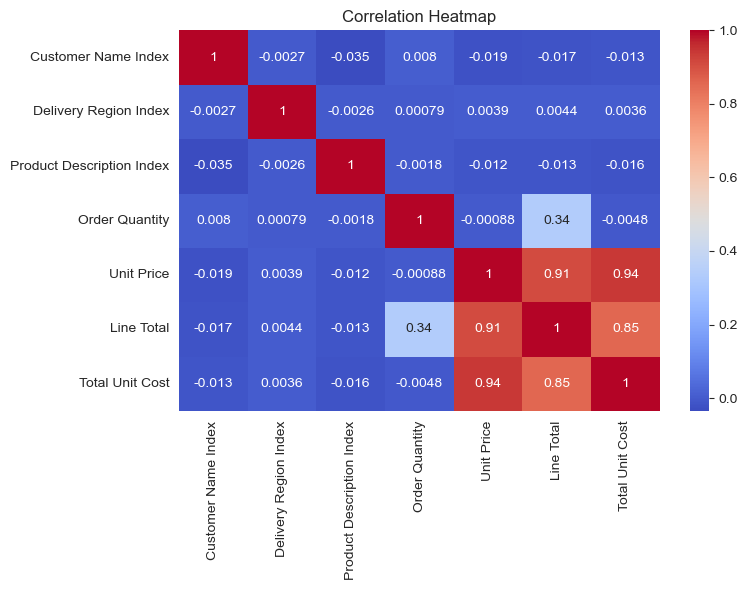

In [13]:
numeric=df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

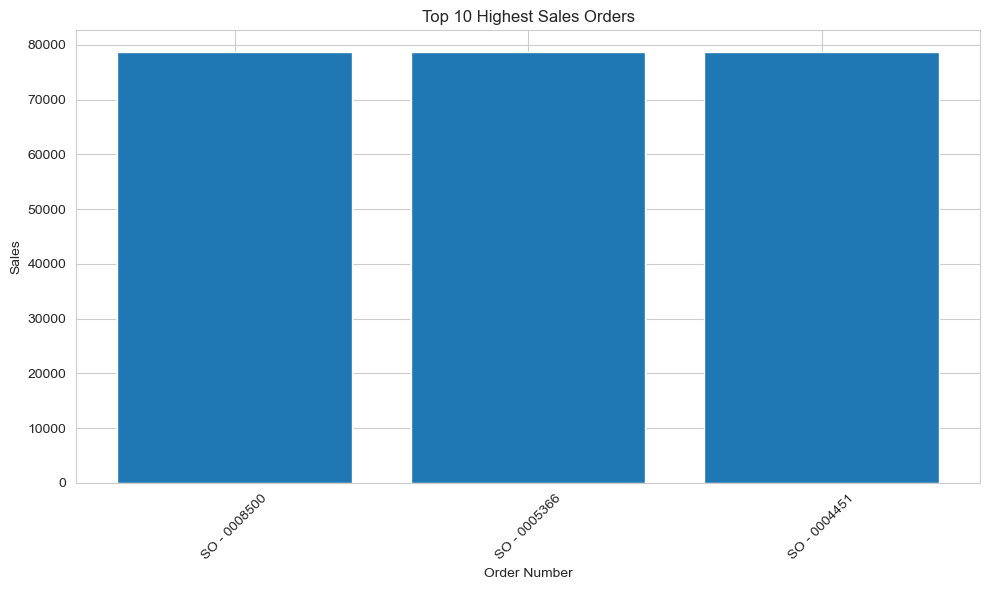

In [14]:
top_orders=df.sort_values("Line Total",ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_orders["OrderNumber"].astype(str),top_orders["Line Total"])
plt.title("Top 10 Highest Sales Orders")
plt.xlabel("Order Number")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print("="*60)
print("REGIONAL SALES DASHBOARD SUMMARY")
print("="*60)

print("Total Sales:", round(df["Line Total"].sum(),2))
print("Average Sales:", round(df["Line Total"].mean(),2))
print("Highest Sale:", round(df["Line Total"].max(),2))
print("Lowest Sale:", round(df["Line Total"].min(),2))
print("Total Orders:", len(df))
print("Total Products:", df["Product Description Index"].nunique())
print("Total Warehouses:", df["Warehouse Code"].nunique())

REGIONAL SALES DASHBOARD SUMMARY
Total Sales: 1235968899.0
Average Sales: 19280.68
Highest Sale: 78711.6
Lowest Sale: 837.5
Total Orders: 64104
Total Products: 30
Total Warehouses: 4
